<a href="https://colab.research.google.com/github/pitagorasman/Tareas-Computo-Emergente/blob/main/Algoritmos%20Geneticos/Tarea_Algoritmos_Geneticos_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import random
import time
from IPython.display import clear_output


# 1. MOTOR ISAAC CON OBSTÁCULOS STRUCTURALES

class ISAACConsoleCombat:
    def __init__(self, size=15, num_blue=12, num_red=12, w_goal=1.5, con_obstaculos=True):
        self.size = size
        # Matriz: 0=Vacío, 1=Azul, 2=Rojo, 3=Obstáculo
        self.grid = np.zeros((size, size), dtype=int)
        self.w_goal = w_goal

        # Posicionar agentes
        self.blue_agents = [[random.randint(0, 2), random.randint(0, 2)] for _ in range(num_blue)]
        self.red_agents = [[random.randint(size-3, size-1), random.randint(size-3, size-1)] for _ in range(num_red)]

        # Generar trincheras/obstáculos fijos en la franja central
        self.obstaculos = []
        if con_obstaculos:
            # Creamos dos muros/trincheras divisorias cruzadas
            for i in range(6, size - 6):
                self.obstaculos.append([i, size // 3])
                self.obstaculos.append([size - 1 - i, (2 * size) // 3])

        self._update_grid()

    def _update_grid(self):
        self.grid.fill(0)
        # Pintar obstáculos fijos
        for x, y in self.obstaculos: self.grid[x, y] = 3
        # Pintar agentes encima (prioridad visual)
        for x, y in self.blue_agents: self.grid[x, y] = 1
        for x, y in self.red_agents: self.grid[x, y] = 2

    def step(self):
        # Movimiento de Azules (IA Evolucionada) intentando esquivar obstáculos
        for a in self.blue_agents:
            # El AG influye en la probabilidad de marchar directo a la meta o explorar los flancos
            dx = 1 if a[0] < self.size - 1 and random.random() < self.w_goal * 0.3 else random.choice([-1, 0, 1])
            dy = 1 if a[1] < self.size - 1 and random.random() < self.w_goal * 0.3 else random.choice([-1, 0, 1])

            nx, ny = max(0, min(self.size - 1, a[0] + dx)), max(0, min(self.size - 1, a[1] + dy))
            # Solo se mueve si la celda destino NO es un obstáculo estructural (3)
            if [nx, ny] not in self.obstaculos:
                a[0], a[1] = nx, ny

        # Movimiento de Rojos (Enemigo agresivo)
        for a in self.red_agents:
            dx = -1 if a[0] > 0 else random.choice([-1, 0, 1])
            dy = -1 if a[1] > 0 else random.choice([-1, 0, 1])
            nx, ny = max(0, min(self.size - 1, a[0] + dx)), max(0, min(self.size - 1, a[1] + dy))
            if [nx, ny] not in self.obstaculos:
                a[0], a[1] = nx, ny

        self._update_grid()

        # Combate por proximidad inmediata (Vecindad de Moore de rango 1)
        nuevos_azules = []
        for b in self.blue_agents:
            combate = any(abs(b[0] - r[0]) <= 1 and abs(b[1] - r[1]) <= 1 for r in self.red_agents)
            if not (combate and random.random() < 0.35): # 35% letalidad
                nuevos_azules.append(b)

        nuevos_rojos = []
        for r in self.red_agents:
            combate = any(abs(r[0] - b[0]) <= 1 and abs(r[1] - b[1]) <= 1 for b in self.blue_agents)
            if not (combate and random.random() < 0.35):
                nuevos_rojos.append(r)

        self.blue_agents = nuevos_azules
        self.red_agents = nuevos_rojos
        self._update_grid()

    def dibujar_consola(self):
        # Mapeo visual explícito con obstáculos incluidos
        mapeo = {0: "⬜", 1: "🟦", 2: "🟥", 3: "🟫"}
        lineas = []
        for fila in self.grid:
            lineas.append("".join(mapeo[celda] for celda in fila))
        return "\n".join(lineas)


# 2. ALGORITMO GENÉTICO EXPRESS

def evaluar_fitness(w_goal):
    # Simula combates tácticos en un mapa con trincheras para ver qué doctrina sobrevive mejor
    sim = ISAACConsoleCombat(size=14, num_blue=10, num_red=10, w_goal=w_goal, con_obstaculos=True)
    for _ in range(20):
        sim.step()
    return len(sim.blue_agents) - len(sim.red_agents)

def optimizar_doctrina_express():
    print("Iniciando acoplamiento metaheurístico... Evolucionando genes tácticos...")
    poblacion = [random.uniform(0.5, 4.0) for _ in range(4)]

    for gen in range(3): # 3 Generaciones bastan para converger el peso óptimo
        scores = [evaluar_fitness(ind) for ind in poblacion]
        mejor_ind = poblacion[np.argmax(scores)]
        peor_idx = np.argmin(scores)
        # Operador de Mutación Gaussiana simplificada
        poblacion[peor_idx] = max(0.1, mejor_ind + random.uniform(-0.4, 0.4))

    return mejor_ind

# 3. INTERFAZ Y ANIMACIÓN EN TIEMPO REAL

def simulador_consola_interactivo():
    soldados = int(input("Número de soldados por bando (Sugerido 15): ") or 15)

    clear_output()
    mejor_peso_meta = optimizar_doctrina_express()

    print("\n" + "="*55)
    print(f"¡DECISIÓN DEL ALGORITMO GENÉTICO COMPLETADA!")
    print(f"Doctrina Estratégica Óptima Asignada: [w_goal = {mejor_peso_meta:.2f}]")
    print("="*55)
    print("Desplegando batallones en el terreno con obstáculos en 3 segundos...")
    time.sleep(3)

    # Inicializar simulación visual en mapa de 16x16
    sim_visual = ISAACConsoleCombat(size=16, num_blue=soldados, num_red=soldados, w_goal=mejor_peso_meta, con_obstaculos=True)

    for turno in range(45):
        clear_output(wait=True)
        azules = len(sim_visual.blue_agents)
        rojos = len(sim_visual.red_agents)

        print(f"SISTEMA HÍBRIDO AVANZADO (AG + AUTÓMATA CELULAR)")
        print(f"Turno: {turno} | Comando Azul (IA): {azules} vivos | Invasores Rojos: {rojos} vivos\n")
        print(sim_visual.dibujar_consola())
        print("\nLeyenda: 🟦 Unidades Azules | 🟥 Unidades Rojas | 🟫 Trincheras/Obstáculos | ⬜ Terreno Libre")

        if azules == 0 or rojos == 0:
            print("\n¡El enfrentamiento ha concluido!")
            if azules > rojos:
                print("¡Victoria de la doctrina evolucionada del Bando Azul! 🟦🏆")
            elif rojos > azules:
                print("El bando enemigo Rojo ha neutralizado las defensas. 🟥")
            else:
                print("Empate táctico por desgaste mutuo.")
            break

        sim_visual.step()
        time.sleep(0.30) # Velocidad del refresco de fotogramas en consola

# Lanzamiento
simulador_consola_interactivo()

=== SISTEMA HÍBRIDO AVANZADO (AG + AUTÓMATA CELULAR) ===
Turno: 44 | Comando Azul (IA): 9 vivos | Invasores Rojos: 2 vivos

⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜
🟥⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜
⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜
⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜
⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜
⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜
⬜⬜⬜⬜⬜🟫⬜⬜⬜⬜🟫⬜⬜⬜⬜⬜
⬜⬜⬜⬜⬜🟫⬜⬜⬜⬜🟫⬜⬜⬜⬜⬜
⬜⬜⬜⬜⬜🟫⬜⬜⬜⬜🟫⬜⬜⬜⬜⬜
⬜⬜⬜⬜⬜🟫⬜⬜⬜⬜🟫⬜⬜⬜⬜⬜
⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜🟥⬜⬜⬜⬜
⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜
⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜
⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜🟦⬜
⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜🟦🟦🟦
⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜🟦⬜⬜🟦

Leyenda: 🟦 Unidades Azules | 🟥 Unidades Rojas | 🟫 Trincheras/Obstáculos | ⬜ Terreno Libre


/tmp/ipykernel_1517/3875228334.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_effect = np.trapz(profile, t_eval) + length_penalty


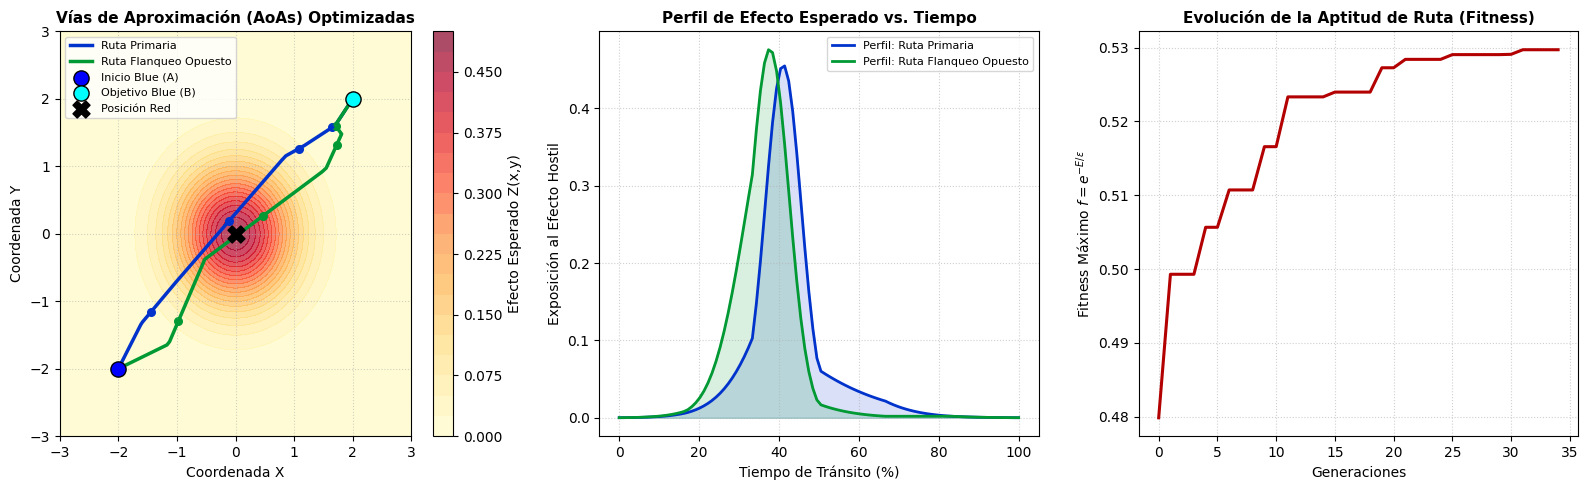

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PARÁMETROS DEL CAMPO DE BATALLA Y MODELO DE EFECTO (RAND TR-423)
# ==============================================================================
START = np.array([-2.0, -2.0])    # Posición inicial de Blue (Punto A)
END   = np.array([2.0, 2.0])      # Objetivo de Blue (Punto B)
RED_POS = np.array([0.0, 0.0])    # Posición estimada del enemigo Red

# Parámetros del Efecto Esperado (Efecto y Niebla de guerra / Incertidumbre)
R_OVER_B = 1.5                    # Ratio de fuerza enemigo/aliado (Capacidad)
SIGMA = 0.5                       # Incertidumbre de posición de Red
LAMBDA = 0.5                      # Rango efectivo de las armas de Red
VARIANCE_EFF = SIGMA**2 + LAMBDA**2
EPSILON = 1.0                     # Disposición al riesgo de Blue

# Parámetros del Algoritmo Genético (Fase 1: Generación de AoAs)
POP_SIZE = 60
GENS = 35
NUM_WAYPOINTS = 5                 # Vértices intermedios por ruta
MUTATION_RATE = 0.35
MUTATION_SIGMA = 0.45

# ==============================================================================
# 2. FUNCIONES DE EVALUACIÓN Y TOPOGRAFÍA DE AMENAZA
# ==============================================================================
def red_expected_effect(x, y):
    """Calcula el Efecto Esperado Z(x, y) de Red como una Gaussiana 2D."""
    norm_sq = (x - RED_POS[0])**2 + (y - RED_POS[1])**2
    amplitude = (R_OVER_B) / (2.0 * np.pi * VARIANCE_EFF)
    return amplitude * np.exp(-norm_sq / (2.0 * VARIANCE_EFF))

def evaluate_route(waypoints, num_samples=100):
    """
    Interpola la ruta completa y calcula:
    - E: Integral del efecto acumulado a lo largo del tiempo (área bajo la curva).
    - profile: Exposición instantánea a lo largo del trayecto.
    - fitness: f = exp(-E / epsilon).
    """
    full_path = np.vstack([START, waypoints, END])
    t_nodes = np.linspace(0, 1, len(full_path))
    t_eval = np.linspace(0, 1, num_samples)

    # Muestreo de trayectoria paramétrica x(t), y(t)
    x_t = np.interp(t_eval, t_nodes, full_path[:, 0])
    y_t = np.interp(t_eval, t_nodes, full_path[:, 1])

    # Perfil de amenaza en cada instante
    profile = red_expected_effect(x_t, y_t)

    # Penalización adicional por longitud excesiva (evita rutas infinitas)
    path_len = np.sum(np.sqrt(np.diff(x_t)**2 + np.diff(y_t)**2))
    length_penalty = 0.1 * path_len

    # Integral de efecto: E = integral dt * Z(x(t))
    total_effect = np.trapz(profile, t_eval) + length_penalty
    fitness = np.exp(-total_effect / EPSILON)

    return fitness, total_effect, profile, (x_t, y_t)

# ==============================================================================
# 3. ALGORITMO GENÉTICO (FASE 1: RUTAS / AOAs)
# ==============================================================================
def run_phase_one_ga():
    # Inicialización: segmentos perturbados estocásticamente
    population = []
    for _ in range(POP_SIZE):
        # Línea recta base entre A y B + ruido aleatorio perpendicular
        alpha = np.linspace(0, 1, NUM_WAYPOINTS + 2)[1:-1, None]
        base_line = (1 - alpha) * START + alpha * END
        noise = np.random.normal(0, 0.7, size=base_line.shape)
        population.append(base_line + noise)

    best_fitness_history = []

    for gen in range(GENS):
        evals = [evaluate_route(ind) for ind in population]
        fitnesses = np.array([e[0] for e in evals])
        best_fitness_history.append(np.max(fitnesses))

        # Selección por Ruleta
        probs = fitnesses / np.sum(fitnesses)
        new_pop = []

        # Elitismo: Preservar los 2 mejores
        elite_indices = np.argsort(fitnesses)[-2:]
        for idx in elite_indices:
            new_pop.append(population[idx].copy())

        while len(new_pop) < POP_SIZE:
            p1_idx = np.random.choice(POP_SIZE, p=probs)
            p2_idx = np.random.choice(POP_SIZE, p=probs)
            parent1, parent2 = population[p1_idx], population[p2_idx]

            # Cruce en un punto sobre los vértices (waypoints)
            cx_point = np.random.randint(1, NUM_WAYPOINTS)
            child = np.vstack([parent1[:cx_point], parent2[cx_point:]])

            # Mutación: perturbación gaussiana de vértices
            if np.random.rand() < MUTATION_RATE:
                mut_idx = np.random.randint(0, NUM_WAYPOINTS)
                child[mut_idx] += np.random.normal(0, MUTATION_SIGMA, size=2)

            new_pop.append(child)

        population = new_pop

    # Obtener las 3 rutas finales más representativas (simulando nichos tácticos)
    final_evals = [evaluate_route(ind) for ind in population]
    sorted_idx = np.argsort([e[0] for e in final_evals])[::-1]

    # Filtrar rutas para mostrar opciones divergentes (Flanco Izquierdo y Flanco Derecho)
    chosen_routes = []
    for idx in sorted_idx:
        _, _, prof, coords = final_evals[idx]
        mean_lateral = np.mean(coords[1] - coords[0]) # Desviación respecto a la diagonal
        if len(chosen_routes) == 0:
            chosen_routes.append((population[idx], prof, coords, "Ruta Primaria"))
        elif len(chosen_routes) == 1 and np.sign(mean_lateral) != np.sign(chosen_routes[0][2][1].mean() - chosen_routes[0][2][0].mean()):
            chosen_routes.append((population[idx], prof, coords, "Ruta Flanqueo Opuesto"))
            break

    if len(chosen_routes) < 2:
        idx_alt = sorted_idx[1]
        chosen_routes.append((population[idx_alt], final_evals[idx_alt][2], final_evals[idx_alt][3], "Ruta Alternativa"))

    return best_fitness_history, chosen_routes

# ==============================================================================
# 4. EJECUCIÓN Y VISUALIZACIÓN GRÁFICA DE LA PRESENTACIÓN
# ==============================================================================
history, routes = run_phase_one_ga()

fig = plt.figure(figsize=(16, 5))

# --- GRÁFICA 1: MAPA TOPOGRÁFICO DE EFECTO Y RUTAS (AOAs) ---
ax1 = fig.add_subplot(1, 3, 1)
x_grid = np.linspace(-3, 3, 150)
y_grid = np.linspace(-3, 3, 150)
X, Y = np.meshgrid(x_grid, y_grid)
Z = red_expected_effect(X, Y)

# Contornos del efecto del enemigo Red
c = ax1.contourf(X, Y, Z, levels=20, cmap='YlOrRd', alpha=0.7)
plt.colorbar(c, ax=ax1, label='Efecto Esperado Z(x,y)')

# Dibujar rutas ganadoras descubiertas
colors = ['#0033cc', '#009933']
for i, (_, _, (xt, yt), label) in enumerate(routes):
    ax1.plot(xt, yt, color=colors[i], linewidth=2.5, label=label)
    ax1.scatter(xt[1:-1:20], yt[1:-1:20], color=colors[i], s=30)

ax1.scatter(*START, color='blue', s=120, edgecolors='black', zorder=5, label='Inicio Blue (A)')
ax1.scatter(*END, color='cyan', s=120, edgecolors='black', zorder=5, label='Objetivo Blue (B)')
ax1.scatter(*RED_POS, color='black', marker='X', s=150, zorder=5, label='Posición Red')
ax1.set_title("Vías de Aproximación (AoAs) Optimizadas", fontsize=11, fontweight='bold')
ax1.set_xlabel("Coordenada X")
ax1.set_ylabel("Coordenada Y")
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, linestyle=':', alpha=0.6)

# --- GRÁFICA 2: PERFIL DE EFECTO EN EL TIEMPO ---
ax2 = fig.add_subplot(1, 3, 2)
time_steps = np.linspace(0, 100, len(routes[0][1]))

for i, (_, prof, _, label) in enumerate(routes):
    ax2.plot(time_steps, prof, color=colors[i], linewidth=2, label=f"Perfil: {label}")
    ax2.fill_between(time_steps, prof, color=colors[i], alpha=0.15)

ax2.set_title("Perfil de Efecto Esperado vs. Tiempo", fontsize=11, fontweight='bold')
ax2.set_xlabel("Tiempo de Tránsito (%)")
ax2.set_ylabel("Exposición al Efecto Hostil")
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, linestyle=':', alpha=0.6)

# --- GRÁFICA 3: CONVERGENCIA DEL ALGORITMO GENÉTICO ---
ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(history, color='#b30000', linewidth=2.2)
ax3.set_title("Evolución de la Aptitud de Ruta (Fitness)", fontsize=11, fontweight='bold')
ax3.set_xlabel("Generaciones")
ax3.set_ylabel(r"Fitness Máximo $f = e^{-E/\epsilon}$")
ax3.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

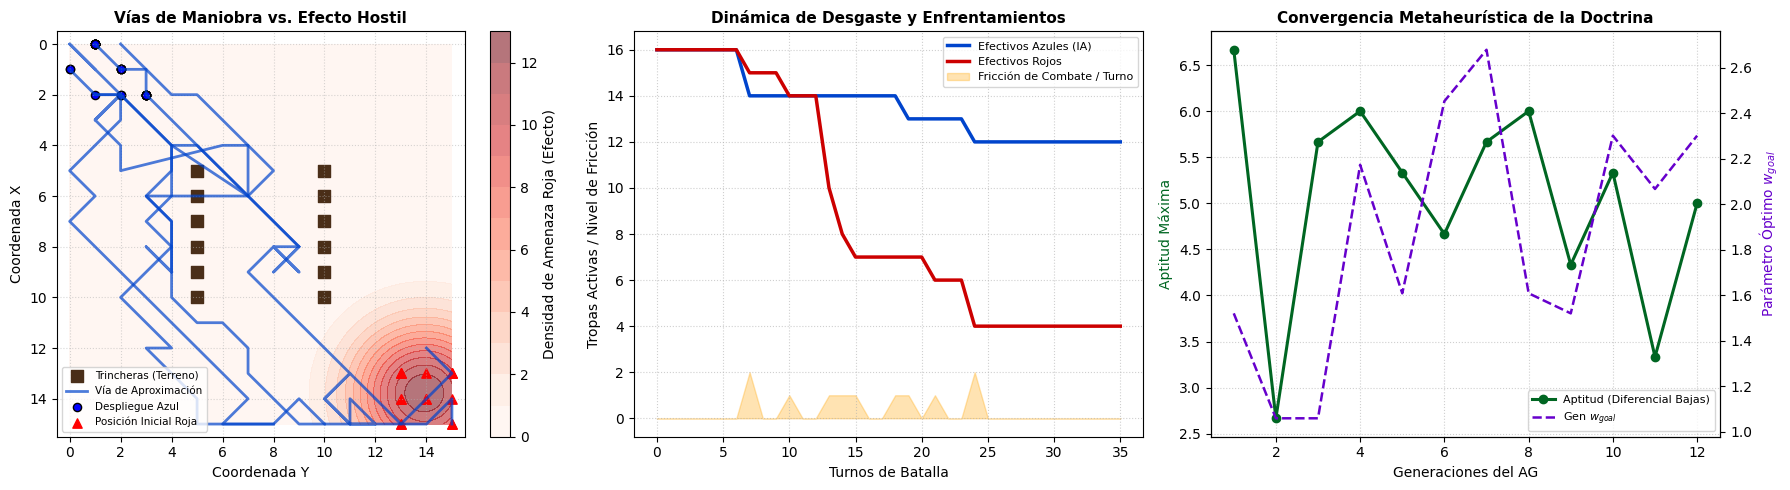

In [3]:
import numpy as np
import random
import matplotlib.pyplot as plt

# ==============================================================================
# 1. MOTOR ISAAC CON REGISTRO DINÁMICO DE TRAYECTORIAS Y ENFRENTAMIENTOS
# ==============================================================================
class ISAACCombatEngine:
    def __init__(self, size=16, num_blue=15, num_red=15, w_goal=1.5, con_obstaculos=True):
        self.size = size
        self.w_goal = w_goal

        # Generación de posiciones iniciales
        self.blue_agents = [[random.randint(0, 2), random.randint(0, 2)] for _ in range(num_blue)]
        self.red_agents = [[random.randint(size-3, size-1), random.randint(size-3, size-1)] for _ in range(num_red)]

        # Guardar posiciones iniciales de Red para el mapa de calor (Efecto Esperado RAND)
        self.initial_red_positions = [list(r) for r in self.red_agents]

        # Trincheras / Obstáculos estructurales (Impassibility)
        self.obstaculos = []
        if con_obstaculos:
            for i in range(5, size - 5):
                self.obstaculos.append([i, size // 3])
                self.obstaculos.append([size - 1 - i, (2 * size) // 3])

        # Historiales para analítica posterior
        self.history_blue_count = [len(self.blue_agents)]
        self.history_red_count = [len(self.red_agents)]
        self.history_combats = [0]
        self.blue_trajectories = [[list(b)] for b in self.blue_agents]

    def step(self):
        # Movimiento de Azules guiados por w_goal optimizado por el AG
        for i, a in enumerate(self.blue_agents):
            dx = 1 if a[0] < self.size - 1 and random.random() < self.w_goal * 0.3 else random.choice([-1, 0, 1])
            dy = 1 if a[1] < self.size - 1 and random.random() < self.w_goal * 0.3 else random.choice([-1, 0, 1])
            nx = max(0, min(self.size - 1, a[0] + dx))
            ny = max(0, min(self.size - 1, a[1] + dy))

            if [nx, ny] not in self.obstaculos:
                a[0], a[1] = nx, ny

            # Registrar coordenada recorrida
            if i < len(self.blue_trajectories):
                self.blue_trajectories[i].append(list(a))

        # Movimiento agresivo de Invasores Rojos
        for a in self.red_agents:
            dx = -1 if a[0] > 0 else random.choice([-1, 0, 1])
            dy = -1 if a[1] > 0 else random.choice([-1, 0, 1])
            nx = max(0, min(self.size - 1, a[0] + dx))
            ny = max(0, min(self.size - 1, a[1] + dy))
            if [nx, ny] not in self.obstaculos:
                a[0], a[1] = nx, ny

        # Resolución de combate por vecindad de Moore
        combates_turno = 0
        nuevos_azules = []
        for b in self.blue_agents:
            combate = any(abs(b[0] - r[0]) <= 1 and abs(b[1] - r[1]) <= 1 for r in self.red_agents)
            if combate:
                combates_turno += 1
            if not (combate and random.random() < 0.35):
                nuevos_azules.append(b)

        nuevos_rojos = []
        for r in self.red_agents:
            combate = any(abs(r[0] - b[0]) <= 1 and abs(r[1] - b[1]) <= 1 for b in self.blue_agents)
            if not (combate and random.random() < 0.35):
                nuevos_rojos.append(r)

        self.blue_agents = nuevos_azules
        self.red_agents = nuevos_rojos

        self.history_blue_count.append(len(self.blue_agents))
        self.history_red_count.append(len(self.red_agents))
        self.history_combats.append(combates_turno)

# ==============================================================================
# 2. ALGORITMO GENÉTICO: BÚSQUEDA Y EVOLUCIÓN DE DOCTRINA
# ==============================================================================
def evaluar_fitness(w_goal, repeticiones=3):
    score_promedio = 0
    for _ in range(repeticiones):
        sim = ISAACCombatEngine(size=16, num_blue=12, num_red=12, w_goal=w_goal, con_obstaculos=True)
        for _ in range(25):
            sim.step()
        score_promedio += (len(sim.blue_agents) - len(sim.red_agents))
    return score_promedio / repeticiones

def optimizar_doctrina_con_historial(generaciones=12, pop_size=8):
    poblacion = [random.uniform(0.5, 3.5) for _ in range(pop_size)]
    historial_fitness = []
    historial_mejores_genes = []

    for _ in range(generaciones):
        scores = [evaluar_fitness(ind) for ind in poblacion]
        idx_max = np.argmax(scores)
        idx_min = np.argmin(scores)

        historial_fitness.append(scores[idx_max])
        historial_mejores_genes.append(poblacion[idx_max])

        # Mutación gaussiana hacia el mejor individuo
        poblacion[idx_min] = max(0.2, min(4.0, poblacion[idx_max] + random.gauss(0, 0.35)))

    mejor_w_goal = poblacion[np.argmax(scores)]
    return mejor_w_goal, historial_fitness, historial_mejores_genes

# ==============================================================================
# 3. EJECUCIÓN Y VISUALIZACIÓN MULTIPANEL (ESTILO RAND TR-423)
# ==============================================================================
# 1) Optimización por AG
mejor_w, hist_fit, hist_genes = optimizar_doctrina_con_historial(generaciones=12, pop_size=8)

# 2) Simulación final con la doctrina óptima
sim = ISAACCombatEngine(size=16, num_blue=16, num_red=16, w_goal=mejor_w, con_obstaculos=True)
for _ in range(35):
    sim.step()

fig = plt.figure(figsize=(18, 5))

# --- GRÁFICA 1: MAPA TOPOGRÁFICO DE EFECTO Y MANIOBRA (AoAs) ---
ax1 = fig.add_subplot(1, 3, 1)

# Construir mapa continuo de amenaza roja usando kernel gaussiano
x = np.linspace(0, sim.size - 1, 100)
y = np.linspace(0, sim.size - 1, 100)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)
for rx, ry in sim.initial_red_positions:
    Z += np.exp(-((X - rx)**2 + (Y - ry)**2) / (2 * (1.8**2)))

c = ax1.contourf(Y, X, Z, levels=15, cmap='Reds', alpha=0.55)
fig.colorbar(c, ax=ax1, label='Densidad de Amenaza Roja (Efecto)')

# Dibujar obstáculos (trincheras)
obs_x = [pt[0] for pt in sim.obstaculos]
obs_y = [pt[1] for pt in sim.obstaculos]
ax1.scatter(obs_y, obs_x, color='#4A2E18', marker='s', s=80, label='Trincheras (Terreno)')

# Trazar trayectorias de avance de unidades azules
for i, path in enumerate(sim.blue_trajectories[:6]):
    px = [p[0] for p in path]
    py = [p[1] for p in path]
    ax1.plot(py, px, color='#0044cc', alpha=0.7, linewidth=2, label='Vía de Aproximación' if i == 0 else "")

ax1.scatter([p[1] for p in sim.blue_trajectories], [p[0] for p in sim.blue_trajectories],
            color='blue', s=35, edgecolors='black', label='Despliegue Azul')
ax1.scatter([r[1] for r in sim.initial_red_positions], [r[0] for r in sim.initial_red_positions],
            color='red', marker='^', s=45, label='Posición Inicial Roja')

ax1.set_xlim(-0.5, sim.size - 0.5)
ax1.set_ylim(sim.size - 0.5, -0.5)  # Invertir eje Y para coincidir con la matriz
ax1.set_title("Vías de Maniobra vs. Efecto Hostil", fontsize=11, fontweight='bold')
ax1.set_xlabel("Coordenada Y")
ax1.set_ylabel("Coordenada X")
ax1.legend(loc='lower left', fontsize=7.5)
ax1.grid(True, linestyle=':', alpha=0.5)

# --- GRÁFICA 2: PERFIL DE FUERZAS Y COMBATES EN EL TIEMPO ---
ax2 = fig.add_subplot(1, 3, 2)
turnos = range(len(sim.history_blue_count))

ax2.plot(turnos, sim.history_blue_count, color='#0044cc', linewidth=2.5, label='Efectivos Azules (IA)')
ax2.plot(turnos, sim.history_red_count, color='#cc0000', linewidth=2.5, label='Efectivos Rojos')
ax2.fill_between(turnos, sim.history_combats, color='orange', alpha=0.3, label='Fricción de Combate / Turno')

ax2.set_title("Dinámica de Desgaste y Enfrentamientos", fontsize=11, fontweight='bold')
ax2.set_xlabel("Turnos de Batalla")
ax2.set_ylabel("Tropas Activas / Nivel de Fricción")
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, linestyle=':', alpha=0.6)

# --- GRÁFICA 3: CONVERGENCIA DEL ALGORITMO GENÉTICO ---
ax3 = fig.add_subplot(1, 3, 3)
gens = range(1, len(hist_fit) + 1)

ax3.plot(gens, hist_fit, color='#006622', marker='o', linewidth=2.2, label='Aptitud (Diferencial Bajas)')
ax3_twin = ax3.twinx()
ax3_twin.plot(gens, hist_genes, color='#6600cc', linestyle='--', linewidth=1.8, label=r'Gen $w_{goal}$')

ax3.set_title("Convergencia Metaheurística de la Doctrina", fontsize=11, fontweight='bold')
ax3.set_xlabel("Generaciones del AG")
ax3.set_ylabel("Aptitud Máxima", color='#006622')
ax3_twin.set_ylabel(r"Parámetro Óptimo $w_{goal}$", color='#6600cc')
ax3.grid(True, linestyle=':', alpha=0.6)

lines_1, labels_1 = ax3.get_legend_handles_labels()
lines_2, labels_2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()